In [1]:
import numpy as np
import pandas as pd, os, datetime

In [2]:

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.dates as mdates
import folium
from adjustText import adjust_text
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

from IPython.display import HTML

In [3]:
profs = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_profile_clusters.csv")

In [4]:
clustered_info = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_spatial_clusters.csv")

In [5]:
curves = pd.read_csv('/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_difference_curves.csv')
curves

,cluster,DUID,hour,mean_diff,mean_diff_lower,mean_diff_upper,median_diff,median_diff_lower,median_diff_upper,station_name,cluster_name
0,0,BOCORWF1,0,0.047383,-0.188582,0.272302,0.123642,-0.246172,0.561812,Boco Rock Wind Farm,Alpine NSW
1,0,BOCORWF1,1,0.091839,-0.155392,0.333684,0.322653,-0.160928,0.719035,Boco Rock Wind Farm,Alpine NSW
2,0,BOCORWF1,2,0.133925,-0.117182,0.378320,0.399703,-0.012489,0.732188,Boco Rock Wind Farm,Alpine NSW
3,0,BOCORWF1,3,0.169432,-0.081401,0.410586,0.421769,-0.038441,0.859444,Boco Rock Wind Farm,Alpine NSW
4,0,BOCORWF1,4,0.223165,-0.029156,0.467538,0.382925,0.028880,0.880424,Boco Rock Wind Farm,Alpine NSW
...,...,...,...,...,...,...,...,...,...,...,...
1315,5,MUSSELR1,19,-0.186139,-0.337528,-0.029120,-0.147246,-0.419948,0.102156,Musselroe Wind Farm,Bass Strait
1316,5,MUSSELR1,20,-0.209915,-0.361429,-0.054157,-0.205077,-0.470687,0.021743,Musselroe Wind Farm,Bass Strait
1317,5,MUSSELR1,21,-0.215731,-0.367932,-0.061927,-0.186293,-0.437389,0.052739,Musselroe Wind Farm,Bass Strait
1318,5,MUSSELR1,22,-0.257422,-0.412463,-0.102307,-0.182080,-0.443415,0.022840,Musselroe Wind Farm,Bass Strait


In [6]:
df = profs.merge(clustered_info[['DUID','cluster','cluster_name','cluster_color']], on='DUID')

In [7]:
cluster_id = 0
dfc = df[df["cluster"] == cluster_id]

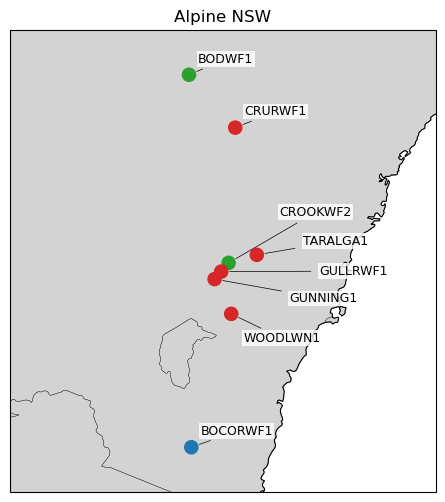

In [8]:
# -------------------
# Auto-zoom extent with padding
# -------------------
pad_lon = 2
pad_lat = 0.5
lon_min, lon_max = dfc["lon"].min() - pad_lon, dfc["lon"].max() + pad_lon
lat_min, lat_max = dfc["lat"].min() - pad_lat, dfc["lat"].max() + pad_lat

# -------------------
# Create figure
# -------------------
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base map
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.STATES, linewidth=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# -------------------
# Plot points
# -------------------
sc = ax.scatter(
    dfc["lon"],
    dfc["lat"],
    c=dfc["profile_color"],
    s=90,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

texts = []
for _, r in dfc.iterrows():
    texts.append(
        ax.text(
            r["lon"],
            r["lat"],
            r["DUID"],
            fontsize=9,
            transform=ccrs.PlateCarree(),
            zorder=6,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1),
        )
    )

# -------------------
# Adjust labels to avoid overlap
# -------------------
adjust_text(
    texts,
    x=dfc["lon"].values,          # points to repel from
    y=dfc["lat"].values,
    ax=ax,
    force_text=(0.7, 0.5),        # stronger text–text repulsion
    force_static=(1.0, 0.7),      # stronger text–point repulsion
    expand=(3, 2),            # expand text bboxes for collision
    min_arrow_len=0.3,
    arrowprops=dict(
        arrowstyle="-",
        lw=0.5,
        shrinkA=6,
        shrinkB=6,
    ),
)

# -------------------
# Title
# -------------------
ax.set_title(dfc.iloc[0]["cluster_name"])
plt.show()

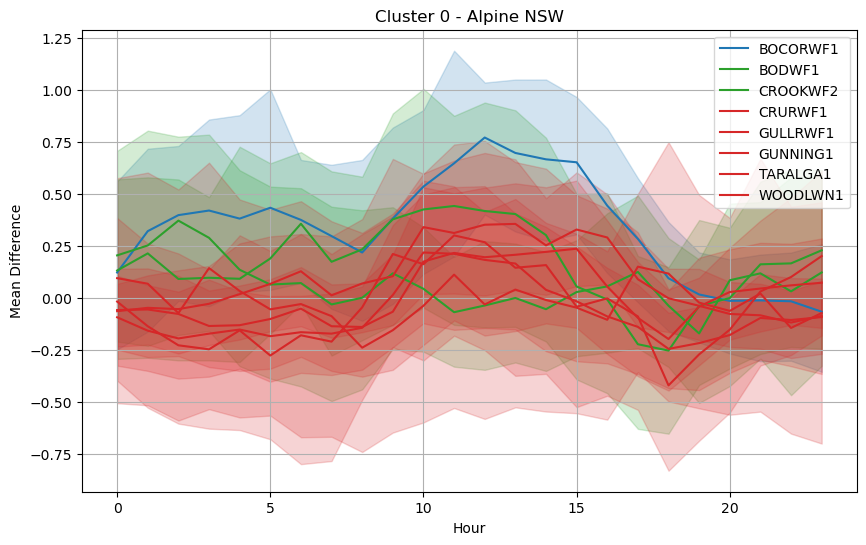

In [9]:
cluster_id = 0
df_cluster = curves[curves["cluster"] == cluster_id]
df_cluster = df_cluster.merge(
    profs[["DUID", "profile_color", "profile_name"]],
    on="DUID",
    how="left"
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for duid, group in df_cluster.groupby("DUID"):
    plt.plot(
        group["hour"],
        group["median_diff"],
        label=duid,
        color=group["profile_color"].iloc[0]
    )
    plt.fill_between(
        group["hour"],
        group["median_diff_lower"],
        group["median_diff_upper"],
        color=group["profile_color"].iloc[0],
        alpha=0.2
    )

plt.xlabel("Hour")
plt.ylabel("Mean Difference")
plt.title(f"Cluster {cluster_id} - {group['cluster_name'].iloc[0]}")
plt.legend()
plt.grid(True)
plt.show()


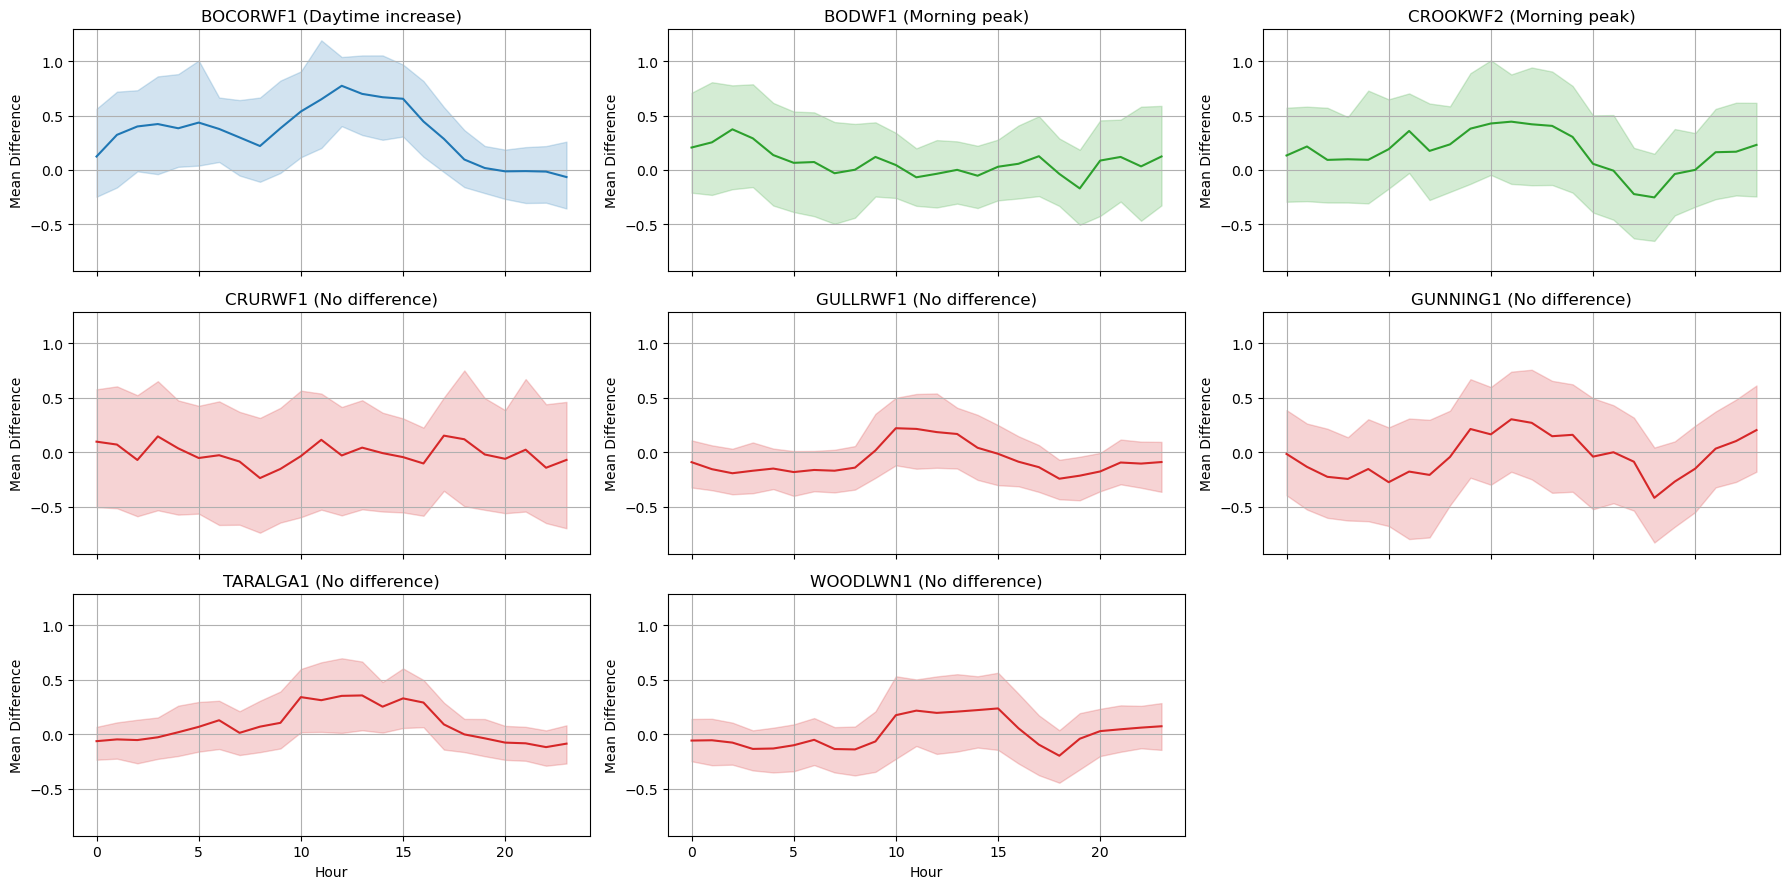

In [10]:
# Unique DUIDs in cluster
duids = df_cluster["DUID"].unique()
n = len(duids)

# Number of columns
ncols = 3
nrows = int(np.ceil(n / ncols))

# Figure and axes
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 3*nrows), sharex=True)
axes = axes.flatten()

# Compute global y-limits for the cluster
ymin = df_cluster["median_diff_lower"].min()
ymax = df_cluster["median_diff_upper"].max()
padding = (ymax - ymin) * 0.05  # 5% padding
ymin -= padding
ymax += padding

# Plot each DUID
for ax, duid in zip(axes, duids):
    group = df_cluster[df_cluster["DUID"] == duid]
    
    # Line
    ax.plot(
        group["hour"],
        group["median_diff"],
        color=group["profile_color"].iloc[0],
        label=duid
    )
    
    # Shaded uncertainty
    ax.fill_between(
        group["hour"],
        group["median_diff_lower"],
        group["median_diff_upper"],
        color=group["profile_color"].iloc[0],
        alpha=0.2
    )
    
    ax.set_title(f"{duid} ({group['profile_name'].iloc[0]})")
    ax.set_ylabel("Mean Difference")
    ax.set_ylim(ymin, ymax)  # same y-scale for all
    ax.grid(True)

# Hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

# Shared x-axis label
for ax in axes[-ncols:]:
    ax.set_xlabel("Hour")

plt.tight_layout()
plt.show()

In [11]:
profs

,DUID,profiles,lat,lon,profile_name,profile_color
0,ARWF1,4,-37.238518,143.079431,No difference,#d62728
1,BALDHWF1,4,-38.790800,145.927700,No difference,#d62728
2,BLUFF1,4,-33.369331,138.982476,No difference,#d62728
3,BOCORWF1,1,-36.576955,149.125867,Daytime increase,#1f77b4
4,BODWF1,3,-32.414600,149.099795,Morning peak,#2ca02c
5,BULGANA1,3,-37.118103,142.960530,Morning peak,#2ca02c
6,CHYTWF1,4,-37.099382,145.267835,No difference,#d62728
7,CLEMGPWF,3,-33.508568,138.119175,Morning peak,#2ca02c
8,CNUNDAWF,1,-37.760253,140.403311,Daytime increase,#1f77b4
9,COOPGWF1,5,-26.733227,151.472270,All-day low,#9467bd
